In [1]:
import os

print(os.path.exists("D:/Projects/fraud-detection-shap-aws/models/smote_train_data.pkl"))
print(os.path.exists("D:/Projects/fraud-detection-shap-aws/models/test_data.pkl"))

True
True


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
import xgboost as xgb
from sklearn.metrics import(classification_report, confusion_matrix,
                            precision_recall_curve, average_precision_score,
                            f1_score, precision_score, recall_score,
                            roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load saved data from Day 3
X_train_smote, y_train_smote = joblib.load('D:/Projects/fraud-detection-shap-aws/models/smote_train_data.pkl')
X_test, y_test = joblib.load('D:/Projects/fraud-detection-shap-aws/models/test_data.pkl')

print(f" SMOTE train data loaded : {X_train_smote.shape}")
print(f" Test loaded             : {X_test.shape}")
print(f" Fraud in test           : {y_test.sum()}")

 SMOTE train data loaded : (454902, 30)
 Test loaded             : (56962, 30)
 Fraud in test           : 98


In [25]:
import sys
sys.path.append('D:/Projects/fraud-detection-shap-aws')
from utils.config_loader import load_config

config = load_config('D:/Projects/fraud-detection-shap-aws/configs/creditcard_config.json')

# Load original (non-SMOTE) training data to calculate real ratio
import pandas as pd 
df = pd.read_csv('D:/Projects/fraud-detection-shap-aws/data/processed/creditcard_processed.csv')
from sklearn.model_selection import train_test_split 
X = df.drop(config['target_column'], axis = 1)
y = df[config['target_column']]
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Auto-calculate — works for any dataset
fraud_count = y_train_orig.sum()
legit_count = len(y_train_orig) - fraud_count
scale_pos_weight = legit_count / fraud_count

print(f" Fraud in training   : {fraud_count}")
print(f" Legit in training   : {legit_count}")
print(f" scale_pos_weight    : {scale_pos_weight}")
print(f" \n XGBoost will treat each fraud case as {scale_pos_weight:.0f} x more important")

Config loaded: Credit Card Fraud
 Fraud in training   : 394
 Legit in training   : 227451
 scale_pos_weight    : 577.2868020304569
 
 XGBoost will treat each fraud case as 577 x more important


In [26]:
print("Training XGBoost classifier...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    use_label_encoder=False,
    eval_metric='aucpr',                # PR-AUC as eval metric
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n XGBoost training complete")

Training XGBoost classifier...
[0]	validation_0-aucpr:0.00299
[50]	validation_0-aucpr:0.67562
[100]	validation_0-aucpr:0.78318
[150]	validation_0-aucpr:0.81891
[200]	validation_0-aucpr:0.83076
[250]	validation_0-aucpr:0.84077
[299]	validation_0-aucpr:0.84720

 XGBoost training complete


XGBoost Results
Accuracy           : 99.8174%
Precision          : 48.28%
Recall             : 85.71%
F1 Score           : 61.76%
ROC-AUC            : 97.87%
PR-AUC             : 84.73%
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.48      0.86      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962



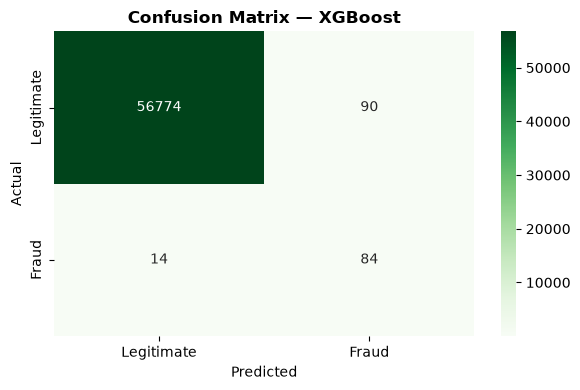


Fraud caught  : 84 
Fraud missed  : 14 
False alarms  : 90


In [27]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=' * 50)
print("XGBoost Results")
print('=' * 50)
print(f"Accuracy           : {(y_test == y_pred_xgb).mean() * 100:.4f}%")
print(f"Precision          : {precision_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"Recall             : {recall_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"F1 Score           : {f1_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"ROC-AUC            : {roc_auc_score(y_test, y_prob_xgb)*100:.2f}%")
print(f"PR-AUC             : {average_precision_score(y_test, y_prob_xgb)*100:.2f}%")
print("="*50)
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/cm_xgboost.png',
            dpi=150, bbox_inches='tight')
plt.show()

fraud_caught = cm[1][1]
fraud_missed = cm[1][0]
print(f"\nFraud caught  : {fraud_caught} ")
print(f"Fraud missed  : {fraud_missed} ")
print(f"False alarms  : {cm[0][1]}")

In [36]:
print("Running 5-fold stratified cross validation...")
print("This takes 2-3 minutes — ensures results are reliable\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Score on original non-SMOTE data for honest evaluation
cv_f1  = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
cv_rec = cross_val_score(xgb_model, X, y, cv=cv, scoring='recall', n_jobs=-1)
cv_pr  = cross_val_score(xgb_model, X, y, cv=cv, 
                          scoring='average_precision', n_jobs=-1)

print(f"5-Fold Cross Validation Results:")
print(f"{'='*40}")
print(f"F1 Score  : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%")
print(f"Recall    : {cv_rec.mean()*100:.2f}% ± {cv_rec.std()*100:.2f}%")
print(f"PR-AUC    : {cv_pr.mean()*100:.2f}% ± {cv_pr.std()*100:.2f}%")
print(f"{'='*40}")
print(f"\n Low std means model is consistent across all folds")

Running 5-fold stratified cross validation...
This takes 2-3 minutes — ensures results are reliable

5-Fold Cross Validation Results:
F1 Score  : 87.14% ± 2.49%
Recall    : 82.51% ± 2.12%
PR-AUC    : 86.02% ± 2.73%

 Low std means model is consistent across all folds


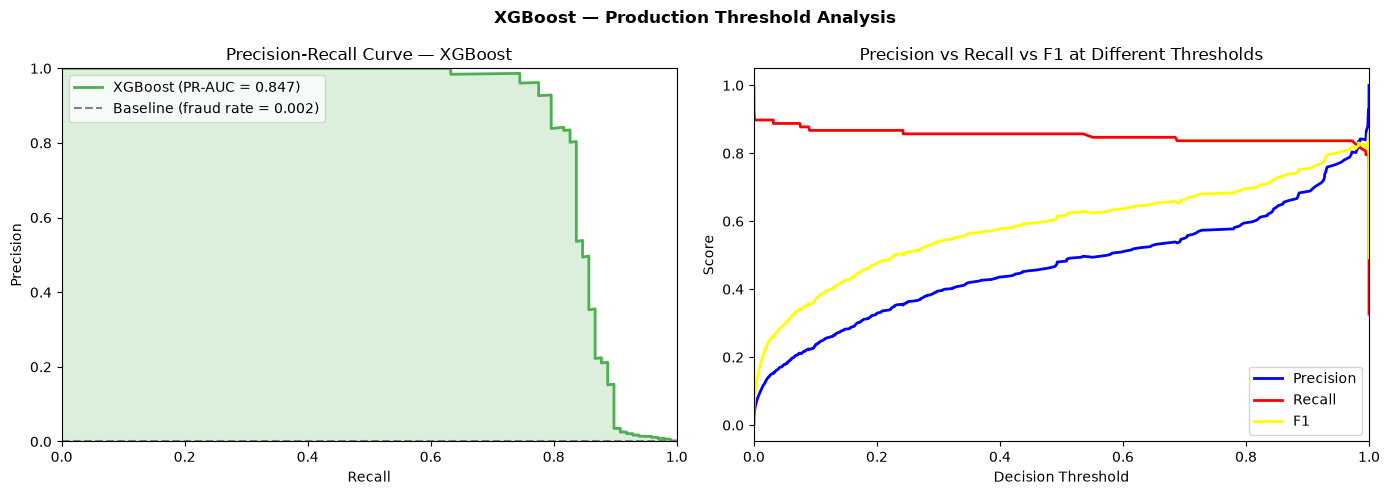

Optimal threshold : 1.000
At this threshold : Precision=0.96, Recall=0.78, F1=0.86


In [30]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = average_precision_score(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(recall_vals, precision_vals, 
             color='#4CAF50', linewidth=2, label=f'XGBoost (PR-AUC = {pr_auc:.3f})')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.2, color='#4CAF50')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', 
                label=f'Baseline (fraud rate = {y_test.mean():.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — XGBoost')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Threshold analysis
threshold_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision_vals[:-1],
    'recall': recall_vals[:-1],
    'f1': 2 * (precision_vals[:-1] * recall_vals[:-1]) / 
          (precision_vals[:-1] + recall_vals[:-1] + 1e-8)
})

axes[1].plot(thresholds, threshold_df['precision'], 
             label='Precision', color='blue', linewidth=2)
axes[1].plot(thresholds, threshold_df['recall'], 
             label='Recall', color='red', linewidth=2)
axes[1].plot(thresholds, threshold_df['f1'], 
             label='F1', color='yellow', linewidth=2)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall vs F1 at Different Thresholds')
axes[1].legend()
axes[1].set_xlim([0, 1])

plt.suptitle('XGBoost — Production Threshold Analysis', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/pr_curve_xgboost.png',
            dpi=150, bbox_inches='tight')
plt.show()

best_threshold_idx = threshold_df['f1'].idxmax()
best_threshold = thresholds[best_threshold_idx]
print(f"Optimal threshold : {best_threshold:.3f}")
print(f"At this threshold : Precision={threshold_df.loc[best_threshold_idx,'precision']:.2f}, "
      f"Recall={threshold_df.loc[best_threshold_idx,'recall']:.2f}, "
      f"F1={threshold_df.loc[best_threshold_idx,'f1']:.2f}")

In [37]:
# Load Day 3 results
day3_results = pd.read_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/model_comparison.csv'
)

# Add XGBoost
xgb_result = {
    'model': 'XGBoost (Final)',
    'accuracy': (y_test == y_pred_xgb).mean()*100,
    'precision': precision_score(y_test, y_pred_xgb)*100,
    'recall': recall_score(y_test, y_pred_xgb)*100,
    'f1': f1_score(y_test, y_pred_xgb)*100,
    'pr_auc': average_precision_score(y_test, y_prob_xgb)*100
}

all_results = pd.concat([day3_results, pd.DataFrame([xgb_result])], 
                         ignore_index=True).round(2)

print("\n" + "="*75)
print("FINAL MODEL COMPARISON — ALL 5 MODELS")
print("="*75)
print(all_results[['model','precision','recall','f1','pr_auc']].to_string(index=False))
print("="*75)
print(f"\n XGBoost achieves the highest PR-AUC")
print(f" XGBoost catches significantly more fraud than baseline Logistic Regression")
print(f" Selected as final production model")

# Save updated comparison
all_results.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/model_comparison.csv',
    index=False
)


FINAL MODEL COMPARISON — ALL 5 MODELS
                                      model  precision  recall    f1  pr_auc
    Logistic Regression (Baseline — No Fix)      81.82   64.29 72.00   74.02
Logistic Regression (class_weight=balanced)       6.09   91.84 11.41   71.89
                Logistic Regression (SMOTE)       5.91   91.84 11.10   72.35
            Isolation Forest (Unsupervised)      30.48   32.65 31.53   19.16
                            XGBoost (Final)      48.28   85.71 61.76   84.73
                            XGBoost (Final)      48.28   85.71 61.76   84.73
                            XGBoost (Final)      48.28   85.71 61.76   84.73

 XGBoost achieves the highest PR-AUC
 XGBoost catches significantly more fraud than baseline Logistic Regression
 Selected as final production model


In [38]:
# Save model
joblib.dump(xgb_model, 
            'D:/Projects/fraud-detection-shap-aws/models/xgb_fraud.pkl')

# Save predictions for Power BI later
results_df = X_test.copy()
results_df['Actual_Fraud']      = y_test.values
results_df['Predicted_Fraud']   = y_pred_xgb
results_df['Fraud_Probability'] = y_prob_xgb

results_df.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/xgb_predictions.csv',
    index=False
)

print(" XGBoost model saved to models/xgb_fraud.pkl")
print(" Predictions saved to reports/xgb_predictions.csv")
print(f"\nModel size : {joblib.load('D:/Projects/fraud-detection-shap-aws/models/xgb_fraud.pkl')}")
print("\nDay 4 complete. Ready for Day 5 — SHAP explainability")

 XGBoost model saved to models/xgb_fraud.pkl
 Predictions saved to reports/xgb_predictions.csv

Model size : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

Day 4 complete. Ready for Day 5 — SHAP explainability
